<a href="https://colab.research.google.com/github/Poonam4385/CIFAR10_CNN_PyTorch/blob/main/CIFAR10_CNN_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [2]:
#PyTorch tensor
import torch

x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

print(x)

print("Shape:", x.shape)

print("Dimensions:", x.ndim)

print("Data type:", x.dtype)

tensor([[1, 2, 3],
        [4, 5, 6]])
Shape: torch.Size([2, 3])
Dimensions: 2
Data type: torch.int64


In [3]:
# Create a tensor for an image
image = torch.rand(3, 224, 224)

print("Image shape:", image.shape)

Image shape: torch.Size([3, 224, 224])


In [4]:
# Batch of images
batch = torch.rand(32, 3, 224, 224)

print("Batch shape:", batch.shape)

Batch shape: torch.Size([32, 3, 224, 224])


In [5]:
# Dataset and DataLoader
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Convert images to PyTorch tensors
transform = transforms.ToTensor()

# Download training dataset
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download test dataset
test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

100%|██████████| 170M/170M [23:59<00:00, 118kB/s]


Training images: 50000
Testing images: 10000


In [6]:
# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 1563
Testing batches: 313


In [7]:
# Look at one batch
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("First 10 labels:")
print(labels[:10])

Images shape: torch.Size([32, 3, 32, 32])
Labels shape: torch.Size([32])
First 10 labels:
tensor([8, 9, 9, 3, 7, 4, 0, 2, 7, 9])


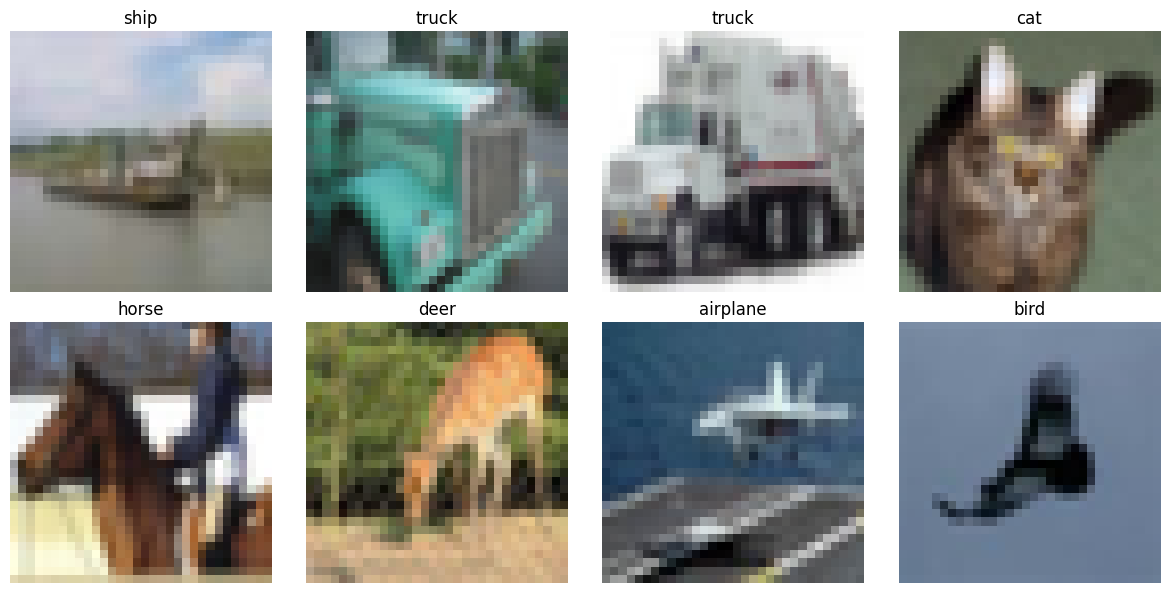

In [8]:
# Display CIFAR-10 images
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    # PyTorch: [C, H, W]
    # Matplotlib: [H, W, C]
    image = images[i].permute(1, 2, 0)

    plt.imshow(image)
    plt.title(class_names[labels[i].item()])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
image = images[i].permute(1, 2, 0)

In [10]:
# Build your first PyTorch CNN
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        # Convolution layer 1
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Convolution layer 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Max pooling
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully connected layers
        self.fc1 = nn.Linear(
            64 * 8 * 8,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

        self.relu = nn.ReLU()


    def forward(self, x):

        # 32x32 → 16x16
        x = self.pool(
            self.relu(self.conv1(x))
        )

        # 16x16 → 8x8
        x = self.pool(
            self.relu(self.conv2(x))
        )

        # Flatten
        x = torch.flatten(x, 1)

        # Dense layer
        x = self.relu(self.fc1(x))

        # Output
        x = self.fc2(x)

        return x

In [11]:
model = CNN()

print(model)


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [12]:
# Loss function and optimizer
import torch.optim as optim

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [13]:
# Use GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

Using device: cuda


In [14]:
# Train the CNN
epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move data to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Add loss
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 1.4248 Accuracy: 48.35%
Epoch [2/10] Loss: 1.0639 Accuracy: 62.09%
Epoch [3/10] Loss: 0.9239 Accuracy: 67.38%
Epoch [4/10] Loss: 0.8257 Accuracy: 70.74%
Epoch [5/10] Loss: 0.7501 Accuracy: 73.50%
Epoch [6/10] Loss: 0.6781 Accuracy: 76.06%
Epoch [7/10] Loss: 0.6184 Accuracy: 77.99%
Epoch [8/10] Loss: 0.5638 Accuracy: 80.08%
Epoch [9/10] Loss: 0.5095 Accuracy: 81.93%
Epoch [10/10] Loss: 0.4594 Accuracy: 83.66%


In [20]:
# Test accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 69.52%


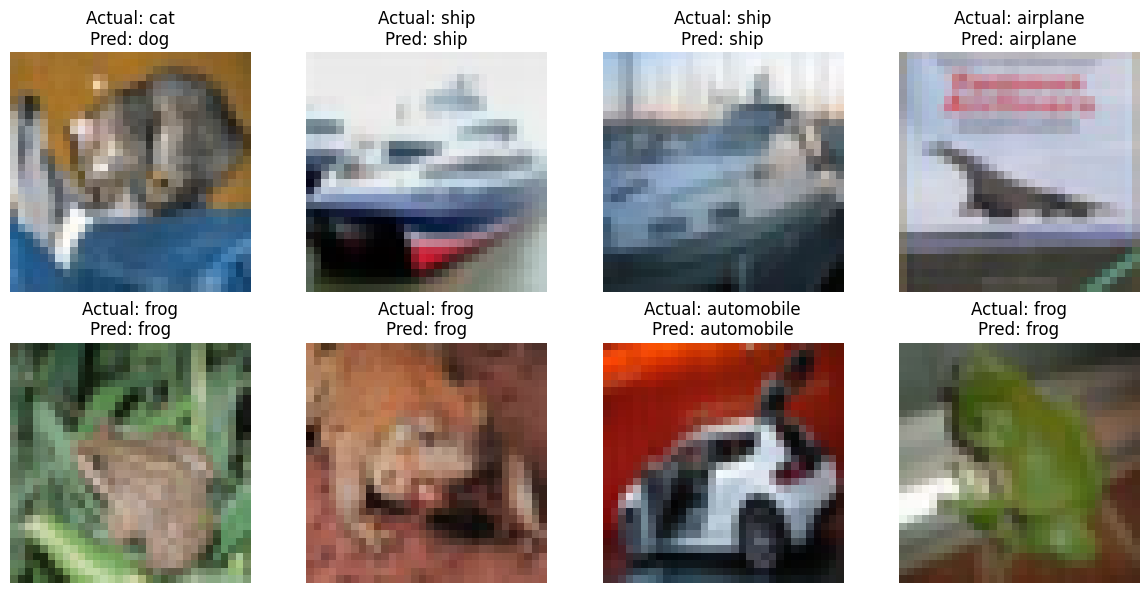

In [19]:
# Test individual images
images, labels = next(iter(test_loader))

images = images.to(device)

outputs = model(images)

_, predicted = torch.max(outputs, 1)

images = images.cpu()
predicted = predicted.cpu()

plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    image = images[i].permute(1, 2, 0)

    plt.imshow(image)

    actual = class_names[labels[i].item()]
    prediction = class_names[predicted[i].item()]

    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {prediction}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# Add data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

In [23]:
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [25]:
# Improved CNN with BatchNorm + Dropout
class ImprovedCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            3, 32, kernel_size=3, padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(
            32, 64, kernel_size=3, padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(
            64, 128, kernel_size=3, padding=1
        )
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(
            128 * 4 * 4,
            256
        )

        self.fc2 = nn.Linear(
            256,
            10
        )

        self.relu = nn.ReLU()


    def forward(self, x):

        x = self.pool(
            self.relu(self.bn1(self.conv1(x)))
        )

        x = self.pool(
            self.relu(self.bn2(self.conv2(x)))
        )

        x = self.pool(
            self.relu(self.bn3(self.conv3(x)))
        )

        x = torch.flatten(x, 1)

        x = self.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [26]:
improved_model = ImprovedCNN().to(device)

print(improved_model)

ImprovedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)


In [27]:
# Loss and optimizer for ImprovedCNN
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    improved_model.parameters(),
    lr=0.001
)

In [28]:
# Train ImprovedCNN
epochs = 15

improved_train_losses = []
improved_train_accuracies = []

for epoch in range(epochs):

    improved_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 1. Clear gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = improved_model(images)

        # 3. Calculate loss
        loss = criterion(outputs, labels)

        # 4. Backpropagation
        loss.backward()

        # 5. Update weights
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    improved_train_losses.append(epoch_loss)
    improved_train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/15] Loss: 1.5946 Accuracy: 40.95%
Epoch [2/15] Loss: 1.2842 Accuracy: 53.71%
Epoch [3/15] Loss: 1.1350 Accuracy: 59.72%
Epoch [4/15] Loss: 1.0442 Accuracy: 63.70%
Epoch [5/15] Loss: 0.9741 Accuracy: 66.21%
Epoch [6/15] Loss: 0.9169 Accuracy: 68.28%
Epoch [7/15] Loss: 0.8766 Accuracy: 69.83%
Epoch [8/15] Loss: 0.8466 Accuracy: 71.04%
Epoch [9/15] Loss: 0.8096 Accuracy: 72.04%
Epoch [10/15] Loss: 0.7890 Accuracy: 73.32%
Epoch [11/15] Loss: 0.7596 Accuracy: 74.32%
Epoch [12/15] Loss: 0.7316 Accuracy: 75.29%
Epoch [13/15] Loss: 0.7198 Accuracy: 75.99%
Epoch [14/15] Loss: 0.6901 Accuracy: 76.84%
Epoch [15/15] Loss: 0.6812 Accuracy: 77.13%


In [29]:
# Test the improved CNN
improved_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = improved_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

improved_test_accuracy = 100 * correct / total

print(
    f"Improved CNN Test Accuracy: "
    f"{improved_test_accuracy:.2f}%"
)

Improved CNN Test Accuracy: 79.65%


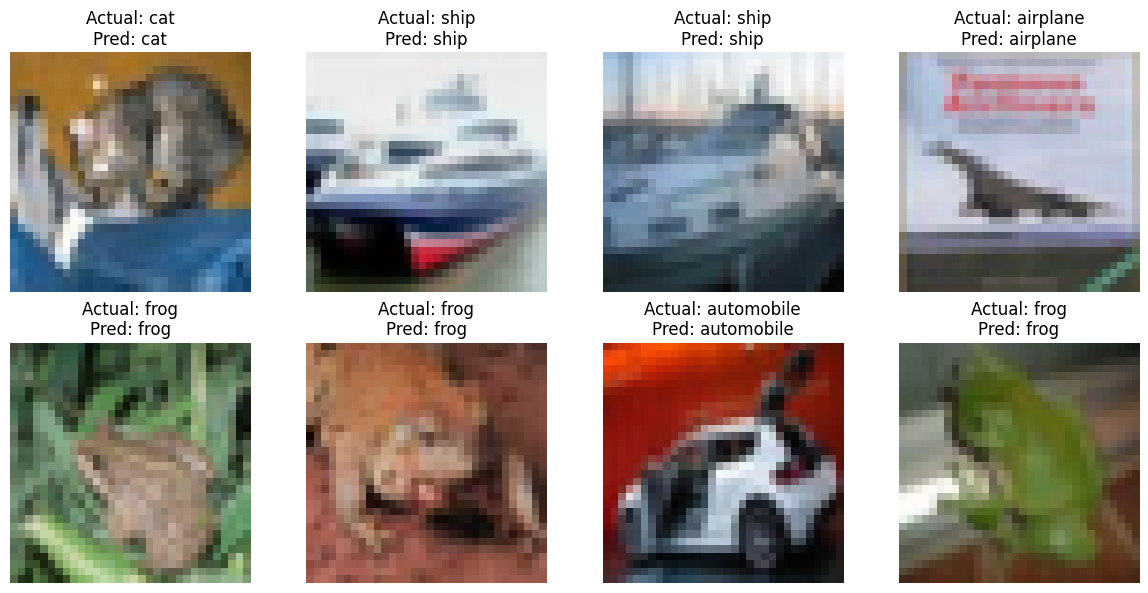

In [30]:
# Test individual images with ImprovedCNN
improved_model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = improved_model(images_device)
    _, predicted = torch.max(outputs, 1)

predicted = predicted.cpu()

plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    image = images[i].permute(1, 2, 0)

    plt.imshow(image)

    actual = class_names[labels[i].item()]
    prediction = class_names[predicted[i].item()]

    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {prediction}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
# Save your trained PyTorch model
torch.save(
    improved_model.state_dict(),
    "cifar10_improved_cnn.pth"
)

print("Model saved successfully!")

Model saved successfully!


In [32]:
loaded_model = ImprovedCNN().to(device)

loaded_model.load_state_dict(
    torch.load(
        "cifar10_improved_cnn.pth",
        map_location=device
    )
)

loaded_model.eval()

print("Model loaded successfully!")

Model loaded successfully!
